In [40]:
DATA_RAW = "../data/raw"
DATA_PROCESSED = "../data/processed"


<!-- Loading the datasets extracted from OpenSky Network -->

**LOADING THE DATASETS**


**FLIGHT DATA- 30/04/2025- Pre Operation Sindoor**

In [41]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(__file__).resolve().parents[1]  # if inside src/
# OR
BASE_DIR = Path.cwd()  # if running from repo root / notebook

before_path = BASE_DIR / "data" / "raw" / "indpak" / "indpak_before_all"


before_files = sorted(before_path.glob("*.csv"))

cols = ["icao24", "callsign", "lat", "lon", "timestamp"]

df_before = pd.concat(
    (
        pd.read_csv(
            f,
            header=None,
            names=cols,
            dtype={
                "icao24": "string",    #Aircraft Identifier
                "callsign": "string",  
                "lat": "float64",      #Latitude
                "lon": "float64",      #Longitude
                "timestamp": "int64"
            }  #Standardizing the datatypes for each column of the schema
        )
        for f in before_files
    ),
    ignore_index=True
)

df_before["phase"] = "before"      #Tagging the rows for ease of identification and classification 

df_before["datetime"] = pd.to_datetime(
    df_before["timestamp"], unit="s", utc=True
)

df_before.shape



(18901542, 7)

<!-- Dataset Description -->

**FLIGHT DATA- 07/05/2025-09/05/2025 During Operation Sindoor**

In [42]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path(__file__).resolve().parents[1]  # if inside src/
# OR
BASE_DIR = Path.cwd()  # if running from repo root / notebook

during_path = BASE_DIR / "data" / "raw" / "indpak" / "indpak_during_all"

during_files = sorted(during_path.glob("*.csv"))

cols = ["icao24", "callsign", "lat", "lon", "timestamp"]

df_during = pd.concat(
    (
        pd.read_csv(
            f,
            header=None,
            names=cols,
            dtype={
                "icao24": "string",
                "callsign": "string",
                "lat": "float64",
                "lon": "float64",
                "timestamp": "int64"
            }
        )
        for f in during_files
    ),
    ignore_index=True
)

df_during["phase"] = "during"
df_during["datetime"] = pd.to_datetime(
    df_during["timestamp"], unit="s", utc=True
)

df_during.shape




(58636253, 7)

**FLIGHT DATA- 30/05/2025- Post Operation Sindoor**

In [43]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path(__file__).resolve().parents[1]  # if inside src/
# OR
BASE_DIR = Path.cwd()  # if running from repo root / notebook

after_path = BASE_DIR / "data" / "raw" / "indpak" / "indpak_after_all"

after_files = sorted(after_path.glob("*.csv"))

cols = ["icao24", "callsign", "lat", "lon", "timestamp"]

df_after = pd.concat(
    (
        pd.read_csv(
            f,
            header=None,
            names=cols,
            dtype={
                "icao24": "string",
                "callsign": "string",
                "lat": "float64",
                "lon": "float64",
                "timestamp": "int64"
            }
        )
        for f in after_files
    ),
    ignore_index=True
)

df_after["phase"] = "after"
df_after["datetime"] = pd.to_datetime(
    df_after["timestamp"], unit="s", utc=True
)

df_after.shape




(19856323, 7)

**DATASET DESCRIPTIONS**

In [44]:
df_before.info()
df_before.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 18901542 entries, 0 to 18901541
Data columns (total 7 columns):
 #   Column     Dtype             
---  ------     -----             
 0   icao24     string            
 1   callsign   string            
 2   lat        float64           
 3   lon        float64           
 4   timestamp  int64             
 5   phase      str               
 6   datetime   datetime64[s, UTC]
dtypes: datetime64[s, UTC](1), float64(2), int64(1), str(1), string(2)
memory usage: 1009.5 MB


icao24            0
callsign     631184
lat               0
lon               0
timestamp         0
phase             0
datetime          0
dtype: int64

In [45]:
df_before.head()

,icao24,callsign,lat,lon,timestamp,phase,datetime
0,06a2e4,QTR62X,29.722824,48.116578,1745971201,before,2025-04-30 00:00:01+00:00
1,06a2e4,QTR62X,29.729656,48.112093,1745971202,before,2025-04-30 00:00:02+00:00
2,06a2e4,QTR62X,29.731611,48.110800,1745971203,before,2025-04-30 00:00:03+00:00
3,06a2e4,QTR62X,29.733566,48.109508,1745971204,before,2025-04-30 00:00:04+00:00
4,06a2e4,QTR62X,29.733566,48.109508,1745971205,before,2025-04-30 00:00:05+00:00


In [46]:
df_during.info()


<class 'pandas.DataFrame'>
RangeIndex: 58636253 entries, 0 to 58636252
Data columns (total 7 columns):
 #   Column     Dtype             
---  ------     -----             
 0   icao24     string            
 1   callsign   string            
 2   lat        float64           
 3   lon        float64           
 4   timestamp  int64             
 5   phase      str               
 6   datetime   datetime64[s, UTC]
dtypes: datetime64[s, UTC](1), float64(2), int64(1), str(1), string(2)
memory usage: 3.1 GB


In [47]:
df_during.head()

,icao24,callsign,lat,lon,timestamp,phase,datetime
0,8964da,ABY595,28.215866,44.727402,1746579494,during,2025-05-07 00:58:14+00:00
1,8964da,ABY595,28.215358,44.729919,1746579495,during,2025-05-07 00:58:15+00:00
2,8964da,ABY595,28.215358,44.729919,1746579496,during,2025-05-07 00:58:16+00:00
3,8964da,ABY595,28.215358,44.729919,1746579497,during,2025-05-07 00:58:17+00:00
4,8964da,ABY595,28.215358,44.729919,1746579498,during,2025-05-07 00:58:18+00:00


In [48]:
df_after.info()


<class 'pandas.DataFrame'>
RangeIndex: 19856323 entries, 0 to 19856322
Data columns (total 7 columns):
 #   Column     Dtype             
---  ------     -----             
 0   icao24     string            
 1   callsign   string            
 2   lat        float64           
 3   lon        float64           
 4   timestamp  int64             
 5   phase      str               
 6   datetime   datetime64[s, UTC]
dtypes: datetime64[s, UTC](1), float64(2), int64(1), str(1), string(2)
memory usage: 1.0 GB


In [49]:
df_after.head()

,icao24,callsign,lat,lon,timestamp,phase,datetime
0,4b191a,<NA>,20.747681,81.722051,1748565137,after,2025-05-30 00:32:17+00:00
1,4b191a,<NA>,20.747360,81.724695,1748565138,after,2025-05-30 00:32:18+00:00
2,4b191a,<NA>,20.747360,81.724695,1748565139,after,2025-05-30 00:32:19+00:00
3,4b191a,<NA>,20.746674,81.729845,1748565140,after,2025-05-30 00:32:20+00:00
4,4b191a,<NA>,20.746517,81.731040,1748565141,after,2025-05-30 00:32:21+00:00


**VISUAL ANALYSIS**

**IMPORT NECESSARY LIBRARIES**

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets


In [51]:
#DOWNLOAD GEOPANDAS DATA FOR GEOGRAPHIC OVERLAYS
countries = gpd.read_file(
    "/Users/esangyam/Desktop/Code/OpenSky/data/geo/ne_110m_admin_0_countries.shp"
)

region = countries[countries["NAME"].isin(["India", "Pakistan"])]


In [52]:
land = gpd.read_file(
    geodatasets.get_path("naturalearth.land")
)


In [53]:
# Spatial bounds (Indo–Pak region)
LAT_MIN, LAT_MAX = 20, 40
LON_MIN, LON_MAX = 60, 90

# Grid resolution
N_LAT = 650
N_LON = 650


**Calculating spatial flight density per latitude–longitude box.**

In [54]:
lat_bins = np.linspace(LAT_MIN, LAT_MAX, N_LAT)
lon_bins = np.linspace(LON_MIN, LON_MAX, N_LON)

H_before, lon_edges_bef, lat_edges_bef = np.histogram2d(
    df_before["lon"],   # X-axis
    df_before["lat"],   # Y-axis
    bins=[lon_bins, lat_bins]
)



In [55]:

H_log_before = np.log1p(H_before)


**PLOTTING THE FIGURE FOR FLIGHT TRAJECTORIES PRE EVENT**

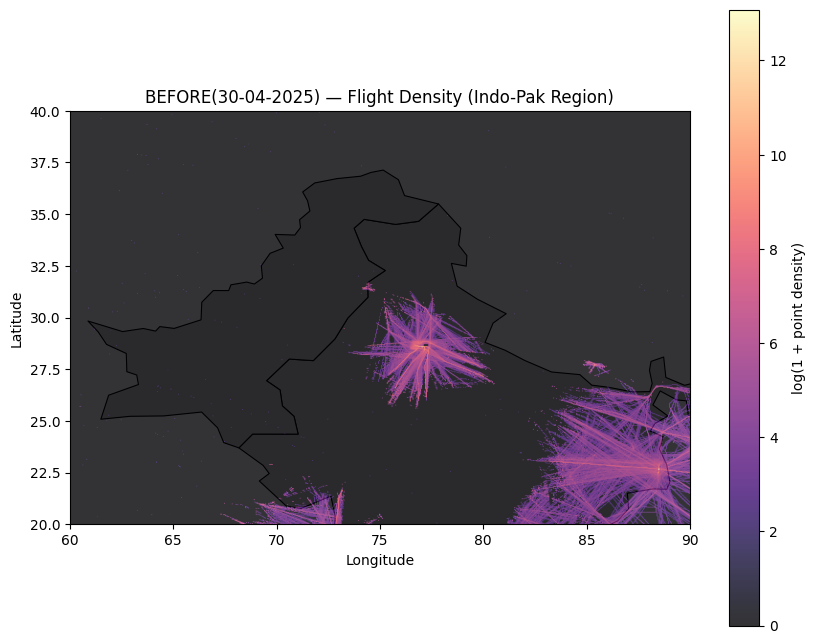

In [56]:
fig, ax = plt.subplots(figsize=(10, 10))

# Countries background
region.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.8,
    zorder=1
)

# Density overlay
im = ax.imshow(
    H_log_before.T,
    origin="lower",
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap="magma",
    alpha=0.8,
    zorder=2
)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal", adjustable="box")

ax.set_title("BEFORE(30-04-2025) — Flight Density (Indo-Pak Region)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("log(1 + point density)")

plt.show()


fig.savefig(
    "indo_pak_route_before.png",
    dpi=300,
    bbox_inches="tight"
)


**What this shows:**  
Baseline flight activity before the conflict period, visualized as log-scaled density.  
Bright regions indicate major air corridors and hubs with consistently high traffic.

**How to read it:**  
Higher intensity = more flight trajectory points passing through that grid cell.  
This serves as the reference against which all deviations are measured.

**NOTE -** Figure shows a significant amount of density over the Pakistani Airspace (Islamabad International Airport) pre Op Sindoor.

**Rep of flight data on 30-04-2025 over a 24 hour window**

In [57]:
lat_bins = np.linspace(LAT_MIN, LAT_MAX, N_LAT)
lon_bins = np.linspace(LON_MIN, LON_MAX, N_LON)

H_during, lon_edges_during, lat_edges_during = np.histogram2d(
    df_during["lon"],   # X-axis
    df_during["lat"],   # Y-axis
    bins=[lon_bins, lat_bins]
)



In [58]:

H_log_during = np.log1p(H_during)


**PLOTTING THE FIGURE FOR FLIGHT TRAJECTORIES DURING THE EVENT**

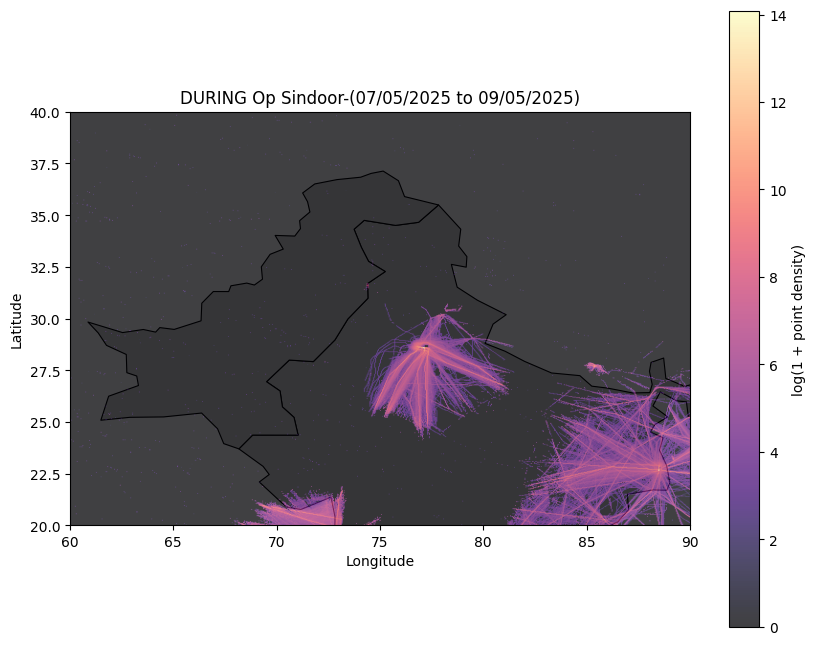

In [59]:
fig, ax = plt.subplots(figsize=(10, 10))

# Countries background
region.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.8,
    zorder=1
)

# Density overlay
im = ax.imshow(
    H_log_during.T,
    origin="lower",
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap="magma",
    alpha=0.75,
    zorder=2
)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal", adjustable="box")

ax.set_title("DURING Op Sindoor-(07/05/2025 to 09/05/2025)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("log(1 + point density)")

plt.show()

fig.savefig(
    "indo_pak_route_during.png",
    dpi=300,
    bbox_inches="tight"
)


**What this shows:**  
Flight density during the conflict window, aggregated over a longer time span.  
Noticeable thinning and reshaping of traffic patterns compared to the baseline.

**Key insight:**  
Traffic redistributes away from sensitive corridors, indicating early rerouting  
and operational caution rather than a uniform drop across the region.

**NOTE -** Figure shows a significant reduction of density over the Pakistani Airspace (Islamabad International Airport) during Op Sindoor (72 hour timeframe).



<!-- NOTE- REDUCED DENSITY OVER PAKISTANI AIRSPACE (ISLAMABAD REGION) -->

In [60]:
lat_bins = np.linspace(LAT_MIN, LAT_MAX, N_LAT)
lon_bins = np.linspace(LON_MIN, LON_MAX, N_LON)

H_after, lon_edges_after, lat_edges_after = np.histogram2d(
    df_after["lon"],   # X-axis
    df_after["lat"],   # Y-axis
    bins=[lon_bins, lat_bins]
)



In [61]:

H_log_after = np.log1p(H_after)


**PLOTTING TRAJECTORIES POST EVENT**

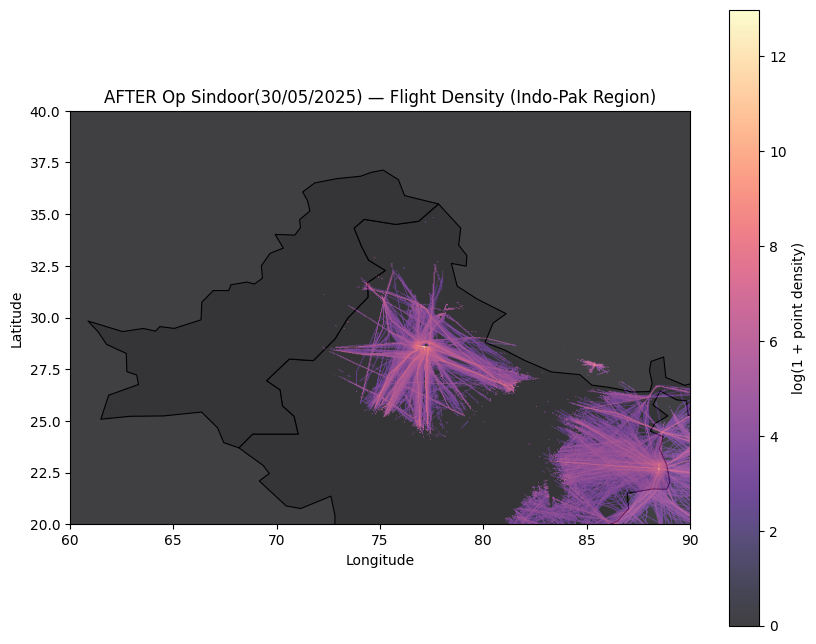

In [62]:
fig, ax = plt.subplots(figsize=(10, 10))

# Countries background
region.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.8,
    zorder=1
)

# Density overlay
im = ax.imshow(
    H_log_after.T,
    origin="lower",
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap="magma",
    alpha=0.75,
    zorder=2
)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal", adjustable="box")

ax.set_title("AFTER Op Sindoor(30/05/2025) — Flight Density (Indo-Pak Region)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("log(1 + point density)")

plt.show()


fig.savefig(
    "indo_pak_route_deviation_after.png",
    dpi=300,
    bbox_inches="tight"
)

**What this shows:**  
Post-conflict flight density as operations begin stabilizing.  
Some corridors recover, while others remain altered.

**Key insight:**  
Recovery is asymmetric — certain routes resume quickly,  
while strategic airspace continues to see reduced utilization.


**Computing change in airspace usage per grid cell relative to BEFORE**

In [65]:
delta_during = H_log_during - H_log_before
delta_after = H_log_after - H_log_before


In [66]:
abs_max = np.percentile(
    np.abs(
        np.concatenate([
            delta_during.ravel(),
            delta_after.ravel()
        ])
    ),
    99
)

VMIN, VMAX = -abs_max, abs_max


**Plotting spatial changes in flight density relative to the *BEFORE* baseline**

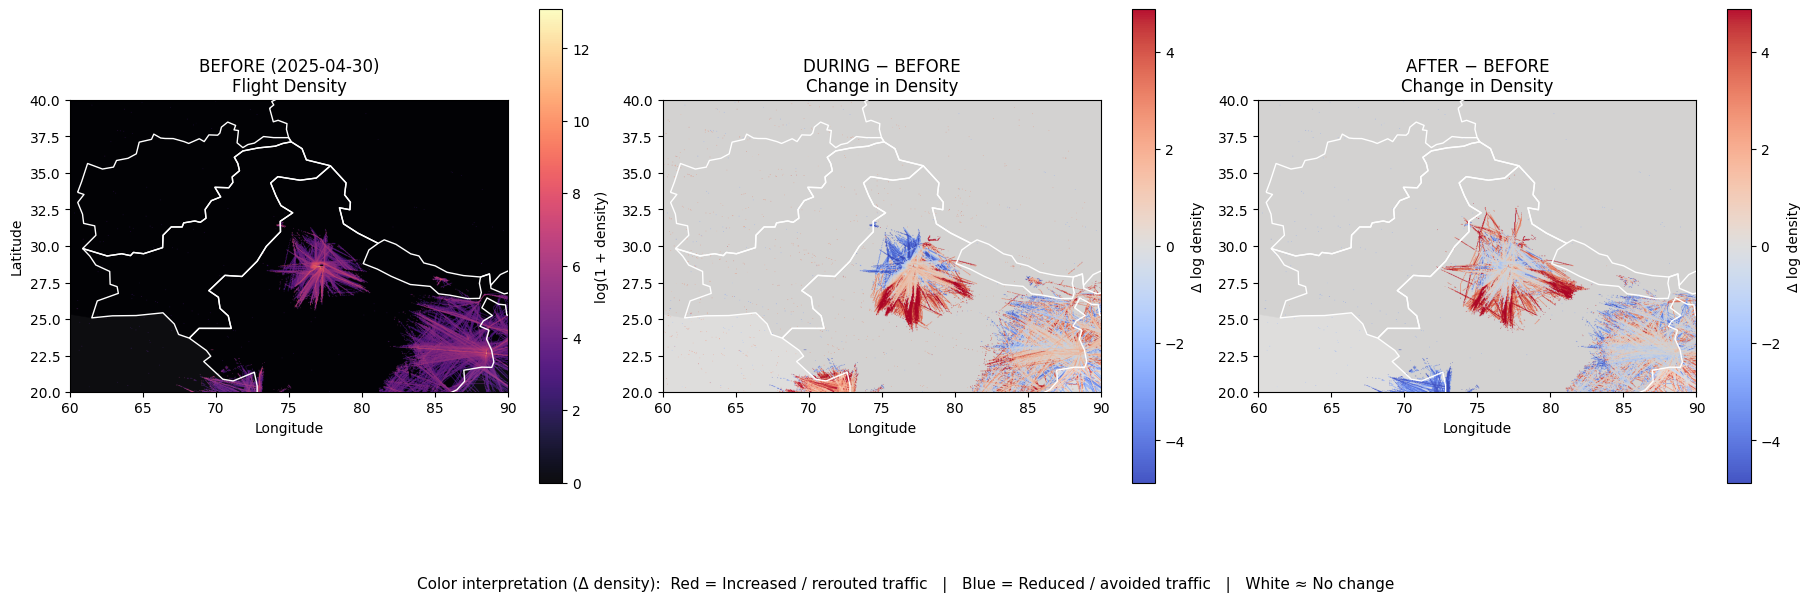

In [67]:
import matplotlib.pyplot as plt
import geopandas as gpd


countries = gpd.read_file(
    "/Users/esangyam/Desktop/Code/OpenSky/data/geo/ne_110m_admin_0_countries.shp"
).to_crs(epsg=4326)

region = countries[countries["NAME"].isin(["India", "Pakistan","China","Afghanistan"])]

# --- Figure ---
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    constrained_layout=True
)

# Helper: draw land + borders consistently
def draw_base(ax):
    land.plot(
        ax=ax,
        facecolor="#2b2b2b",     # dark gray land
        edgecolor="#555555",
        linewidth=0.4,
        zorder=1
    )
    region.boundary.plot(
        ax=ax,
        color="white",
        linewidth=1.0,
        zorder=3
    )
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Longitude")

# ---------- PANEL 1: BEFORE ----------
draw_base(axes[0])

im0 = axes[0].imshow(
    H_log_before.T,
    origin="lower",
    extent=(LON_MIN, LON_MAX, LAT_MIN, LAT_MAX),
    cmap="magma",
    alpha=0.95,
    zorder=2
)

axes[0].set_title("BEFORE (2025-04-30)\nFlight Density")
axes[0].set_ylabel("Latitude")

cbar0 = fig.colorbar(im0, ax=axes[0], shrink=0.8)
cbar0.set_label("log(1 + density)")

# ---------- PANEL 2: DURING − BEFORE ----------
draw_base(axes[1])

im1 = axes[1].imshow(
    delta_during.T,
    origin="lower",
    extent=(LON_MIN, LON_MAX, LAT_MIN, LAT_MAX),
    cmap="coolwarm",
    vmin=VMIN,
    vmax=VMAX,
    alpha=0.95,
    zorder=2
)

axes[1].set_title("DURING − BEFORE\nChange in Density")

cbar1 = fig.colorbar(im1, ax=axes[1], shrink=0.8)
cbar1.set_label("Δ log density")

# ---------- PANEL 3: AFTER − BEFORE ----------
draw_base(axes[2])

im2 = axes[2].imshow(
    delta_after.T,
    origin="lower",
    extent=(LON_MIN, LON_MAX, LAT_MIN, LAT_MAX),
    cmap="coolwarm",
    vmin=VMIN,
    vmax=VMAX,
    alpha=0.95,
    zorder=2
)

axes[2].set_title("AFTER − BEFORE\nChange in Density")

cbar2 = fig.colorbar(im2, ax=axes[2], shrink=0.8)
cbar2.set_label("Δ log density")

fig.text(
    0.5, -0.05,
    "Color interpretation (Δ density):  Red = Increased / rerouted traffic   |   Blue = Reduced / avoided traffic   |   White ≈ No change",
    ha="center",
    va="top",
    fontsize=11
)



plt.show()

fig.savefig(
    "deviation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


### How to Read the Deviation Maps

Each map shows **spatial changes in flight density** relative to the *BEFORE* baseline, computed per grid cell

- **Red regions** → Increase in traffic density  
- **Blue regions** → Decrease in traffic density  
- **White / neutral** → Little or no change  

Color intensity reflects the **magnitude of change**, not absolute traffic volume.

---

### What Each Panel Represents

- **BEFORE**  
  Baseline spatial distribution of flight activity prior to the event.

- **DURING − BEFORE**  
  Immediate disruption effects: airspace avoidance, rerouting, and temporary congestion.

- **AFTER − BEFORE**  
  Persistent or stabilized changes indicating longer-term rerouting or recovery patterns.

---

### What This Reveals

- Traffic reductions (blue) cluster around affected or avoided regions.
- Traffic increases (red) appear along alternative corridors, indicating rerouting.
- Changes are **directional and corridor-based**, not uniformly spread.

**Conclusion:**  
The event caused a structural reconfiguration of regional air traffic, redistributing flows across neighboring airspace rather than eliminating demand.


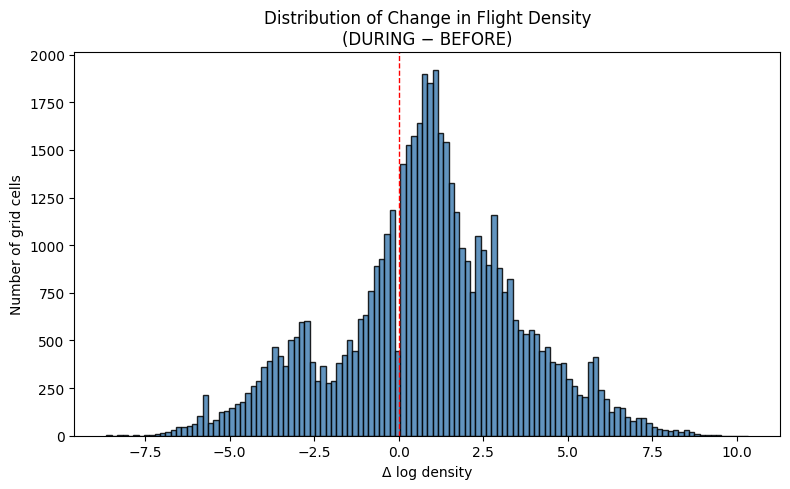

<Figure size 640x480 with 0 Axes>

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten & remove NaNs / zeros
delta_vals = delta_during.flatten()
delta_vals = delta_vals[~np.isnan(delta_vals)]

# Ignore tiny numerical noise
delta_vals = delta_vals[np.abs(delta_vals) > 0.05]

plt.figure(figsize=(8, 5))

plt.hist(
    delta_vals,
    bins=120,
    color="steelblue",
    alpha=0.85,
    edgecolor="black"
)

plt.axvline(0, color="red", linestyle="--", linewidth=1)

plt.title("Distribution of Change in Flight Density\n(DURING − BEFORE)")
plt.xlabel("Δ log density")
plt.ylabel("Number of grid cells")

plt.tight_layout()
plt.show()

plt.savefig(
    "distribution_of_flight_density.png",
    dpi=300,
    bbox_inches="tight"
)

### How to Read This Histogram

Each bar represents the number of spatial grid cells that experienced a given change in flight density, computed as:

**Δ log density = log(1 + DURING traffic) − log(1 + BEFORE traffic)**

- **X-axis (Δ log density)**  
  - `0` → No change  
  - **Positive values** → Increase in traffic  
  - **Negative values** → Decrease in traffic  

- **Y-axis** → Number of grid cells

The red dashed line marks **zero change**.

---

### What This Shows

- The wide distribution indicates **widespread airspace disruption**, not just local effects.
- A strong **right tail** shows traffic concentration in alternative corridors (rerouting).
- A substantial **left tail** shows airspace avoidance in affected regions.
- The peak slightly right of zero suggests redistribution rather than uniform cancellation.

**Conclusion:**  
The conflict reshaped regional air traffic patterns, causing significant rerouting and localized congestion rather than a simple drop in overall flights.


**NOTE**- This visualization highlights airspace corridor criticality rather than airport hub intensity; therefore, high flux over Pakistani airspace reflects concentrated long-haul transit routes, not local airport dominance.